# Fatigue Detection — Lateral Raise Experiment

**Goal:** Detect the onset of deltoid (shoulder) fatigue using shoulder sensor data alone,  
using upper trap activation as objective ground truth for muscular compensation.  

**Sensors:**  Ch1 = right shoulder · Ch2 = right trap · Ch3 = left shoulder · Ch4 = left trap  
**Dataset:** Arthur Thorfinn (4 trials) · Brian Nguyen (4 trials) · 1000 Hz · ~63 s/trial

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

from parse_and_plot import load_trial, FS, COLUMNS
from rep_segmentation import get_reps
from features import extract_per_rep_features
from fatigue_score import compute_fatigue_score, trial_summary, threshold_sweep

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f9f9f9',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

SENSOR_COLORS = {
    'right_shoulder': '#4C72B0',
    'right_trap':     '#DD8452',
    'left_shoulder':  '#55A868',
    'left_trap':      '#C44E52',
}
C_TRAP     = '#C44E52'
C_AMP      = '#4C72B0'
C_TROUGH   = '#E67E22'   # trough duration / rest time
C_WAVEFORM = '#7F8C8D'   # waveform dissimilarity

## 1. Dataset Overview

In [ ]:
DATA_DIR = Path('data')

TRIALS = {
    'Arthur': [
        DATA_DIR / 'Arthur Thorfinn' / 'Trial01.csv',
        DATA_DIR / 'Arthur Thorfinn' / 'Trial02.csv',
        DATA_DIR / 'Arthur Thorfinn' / 'Trial03.csv',
        DATA_DIR / 'Arthur Thorfinn' / 'Trial04.csv',
    ],
    'Brian': [
        DATA_DIR / 'Brian Nguyen' / 'Trial02.csv',  # set 1
        DATA_DIR / 'Brian Nguyen' / 'Trial03.csv',  # set 2
        DATA_DIR / 'Brian Nguyen' / 'Trial05.csv',  # set 3
        DATA_DIR / 'Brian Nguyen' / 'Trial06.csv',  # set 4
    ],
}

# Pre-load all trials
trial_data = {}  # (participant, set_number) -> DataFrame
for participant, paths in TRIALS.items():
    for set_num, path in enumerate(paths, start=1):
        df = load_trial(path)
        trial_data[(participant, set_num)] = df
        print(f"{participant} Set {set_num}: {len(df):,} samples ({len(df)/FS:.1f}s) | "
              f"R_shoulder range {df['right_shoulder'].min():.0f}–{df['right_shoulder'].max():.0f} Ω")

print(f"\nLoaded {len(trial_data)} trials total.")

Arthur Set 1: 62,830 samples (62.8s) | R_shoulder range 607–1187 Ω
Arthur Set 2: 60,920 samples (60.9s) | R_shoulder range 647–1269 Ω
Arthur Set 3: 58,220 samples (58.2s) | R_shoulder range 649–1282 Ω
Arthur Set 4: 59,920 samples (59.9s) | R_shoulder range 631–1383 Ω
Brian Set 1: 45,610 samples (45.6s) | R_shoulder range 621–1594 Ω
Brian Set 2: 41,430 samples (41.4s) | R_shoulder range 650–1781 Ω
Brian Set 3: 39,090 samples (39.1s) | R_shoulder range 668–1823 Ω
Brian Set 4: 35,190 samples (35.2s) | R_shoulder range 685–1853 Ω

Loaded 8 trials total.


: 

: 

: 

## 2. Raw Signal Quality Check
Verify channels are correct: shoulder channels should show strong periodic oscillations; trap channels should be quieter at the start and increase toward failure.

Arthur Set 1 — detected 18 reps  | active window: 0.0s – 62.8s


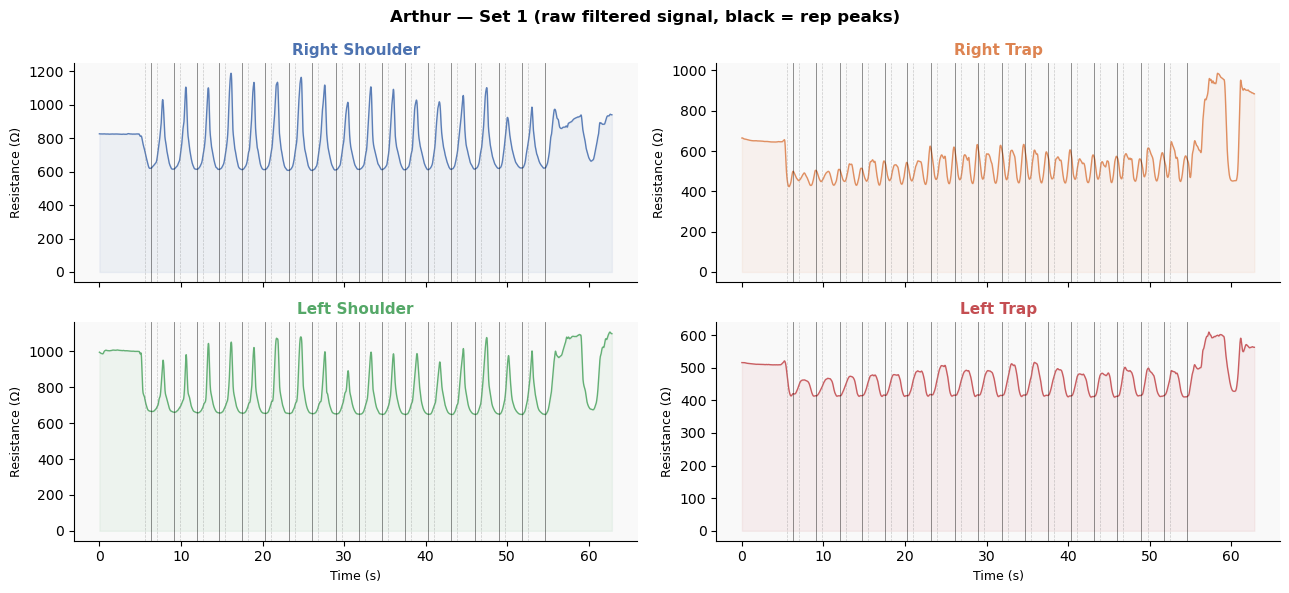

: 

: 

: 

In [ ]:
def plot_raw_trial(df, title='', reps=None):
    fig, axes = plt.subplots(2, 2, figsize=(13, 6), sharex=True)
    axes = axes.flatten()
    time = df.index / FS

    for i, col in enumerate(COLUMNS):
        ax = axes[i]
        color = SENSOR_COLORS[col]
        ax.plot(time, df[col], linewidth=1.0, color=color, alpha=0.9)
        ax.fill_between(time, df[col], alpha=0.07, color=color)
        if reps:
            for start, peak, end in reps:
                ax.axvline(start / FS, color='gray', linewidth=0.5, alpha=0.4, linestyle='--')
                ax.axvline(peak / FS, color='black', linewidth=0.6, alpha=0.5)
        ax.set_title(col.replace('_', ' ').title(), fontsize=11, fontweight='bold', color=color)
        ax.set_ylabel('Resistance (Ω)', fontsize=9)
        if i >= 2:
            ax.set_xlabel('Time (s)', fontsize=9)

    fig.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    return fig

# Show Arthur Set 1 raw signal
df_example = trial_data[('Arthur', 1)]
reps_example, act_start, act_end = get_reps(df_example)
print(f"Arthur Set 1 — detected {len(reps_example)} reps  "
      f"| active window: {act_start/FS:.1f}s – {act_end/FS:.1f}s")
plot_raw_trial(df_example, title='Arthur — Set 1 (raw filtered signal, black = rep peaks)',
               reps=reps_example)
plt.show()

## 3. Rep Segmentation — All Trials

In [ ]:
# Segment all trials and report rep counts
all_reps = {}
for key, df in trial_data.items():
    participant, set_num = key
    reps, act_start, act_end = get_reps(df)
    all_reps[key] = (reps, act_start, act_end)
    durations = [round((e - s) / FS, 2) for s, _, e in reps]
    print(f"{participant} Set {set_num}: {len(reps)} reps  "
          f"| avg rep dur {np.mean(durations):.2f}s ± {np.std(durations):.2f}s  "
          f"| active {act_start/FS:.1f}s–{act_end/FS:.1f}s")

Arthur Set 1: 18 reps  | avg rep dur 4.03s ± 0.44s  | active 0.0s–62.8s
Arthur Set 2: 25 reps  | avg rep dur 2.45s ± 0.95s  | active 0.0s–60.9s
Arthur Set 3: 14 reps  | avg rep dur 5.10s ± 0.73s  | active 0.0s–58.2s
Arthur Set 4: 14 reps  | avg rep dur 5.09s ± 0.71s  | active 0.0s–59.9s
Brian Set 1: 14 reps  | avg rep dur 3.49s ± 0.44s  | active 0.0s–45.6s
Brian Set 2: 12 reps  | avg rep dur 3.37s ± 0.42s  | active 0.0s–41.4s
Brian Set 3: 12 reps  | avg rep dur 3.31s ± 0.54s  | active 0.0s–39.1s
Brian Set 4: 10 reps  | avg rep dur 3.47s ± 0.66s  | active 0.0s–35.2s


: 

: 

: 

## 4. Per-Rep Feature Extraction

In [ ]:
all_features = {}  # key -> features DataFrame with fatigue scores
summaries = []

for key, df in trial_data.items():
    participant, set_num = key
    reps, active_start, active_end = all_reps[key]
    if len(reps) < 4:
        print(f"WARNING: {participant} Set {set_num} has only {len(reps)} reps — skipping.")
        continue
    feat = extract_per_rep_features(df, reps, active_start=active_start)
    feat = compute_fatigue_score(feat)
    feat['participant'] = participant
    feat['set_num'] = set_num
    all_features[key] = feat
    summaries.append(trial_summary(feat, participant, f'Set {set_num}'))

summary_df = pd.DataFrame(summaries)
print(summary_df.to_string(index=False))

: 

: 

: 

## 5. Feature Validation — Which Shoulder Signals Actually Track Fatigue?

Before choosing a shoulder predictor, validate empirically: **does each candidate feature trend with fatigue, and how well does it correlate with the trap compensation signal?**

Candidate features (all normalised to first-3-rep baseline, so 1.0 = baseline):
| Feature | Physical meaning | Expected direction with fatigue |
|---|---|---|
| `inter_rep_interval_s_norm` | Full cycle time (peak-to-peak) | ↑ person unconsciously slows cadence |
| `shoulder_trough_duration_norm` | Time spent at rest within each rep window | ↑ longer rest between lifts |
| `shoulder_rise_time_norm` | Concentric phase speed (arm going up) | ↑ deltoid fires slower |
| `waveform_dissimilarity` | Shape deviation from early-set template | ↑ compensatory movements distort trajectory |

In [ ]:
from scipy.stats import pearsonr

C_INTERVAL = '#1ABC9C'
C_TROUGH   = '#E67E22'
C_RISE     = '#9B59B6'
C_WAVEFORM = '#7F8C8D'

CANDIDATE_FEATURES = {
    'inter_rep_interval_s_norm':    ('Inter-rep interval',   C_INTERVAL),
    'shoulder_trough_duration_norm':('Trough duration',      C_TROUGH),
    'shoulder_rise_time_norm':      ('Rise time',            C_RISE),
    'waveform_dissimilarity':       ('Waveform dissimilarity', C_WAVEFORM),
}

# --- Panel 1: feature trajectories per trial (small multiples) ---
n_trials = len(all_features)
fig, axes = plt.subplots(len(CANDIDATE_FEATURES), n_trials,
                         figsize=(2.5 * n_trials, 2.5 * len(CANDIDATE_FEATURES)),
                         sharex='col')
if n_trials == 1:
    axes = axes[:, np.newaxis]

trial_keys = list(all_features.keys())
for col, key in enumerate(trial_keys):
    participant, set_num = key
    feat = all_features[key]
    reps = feat['rep'].values
    trap = feat['trap_score_smooth'].values

    for row, (feat_col, (label, color)) in enumerate(CANDIDATE_FEATURES.items()):
        ax = axes[row][col]
        if feat_col in feat.columns:
            vals = feat[feat_col].values
            ax.plot(reps, vals, 'o-', color=color, linewidth=1.5, markersize=4)
        ax.axhline(1.0, color='gray', linewidth=0.6, linestyle=':', alpha=0.5)
        trap_onset = feat['trap_onset_rep'].iloc[0]
        if trap_onset:
            ax.axvline(trap_onset, color=C_TRAP, linewidth=1.2, alpha=0.7)
        if row == 0:
            ax.set_title(f'{participant} S{set_num}', fontsize=9, fontweight='bold')
        if col == 0:
            ax.set_ylabel(label, fontsize=8)
        if row == len(CANDIDATE_FEATURES) - 1:
            ax.set_xlabel('Rep', fontsize=8)

fig.suptitle('Shoulder Feature Trajectories per Trial (red line = trap onset)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('output/feature_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved output/feature_trajectories.png")

# --- Panel 2: Pearson r vs trap_score (pooled across all trials) ---
all_combined = pd.concat(all_features.values(), ignore_index=True)
corr_rows = []
for feat_col, (label, _) in CANDIDATE_FEATURES.items():
    if feat_col not in all_combined.columns:
        continue
    valid = all_combined[['trap_score', feat_col]].dropna()
    if len(valid) < 5:
        corr_rows.append({'feature': label, 'pearson_r': np.nan, 'p_value': np.nan, 'n': len(valid)})
        continue
    r, p = pearsonr(valid['trap_score'], valid[feat_col])
    corr_rows.append({'feature': label, 'pearson_r': round(r, 3), 'p_value': round(p, 4), 'n': len(valid)})

corr_df = pd.DataFrame(corr_rows).sort_values('pearson_r', ascending=False)
print("\n=== Feature correlation vs trap_score (pooled across all trials) ===")
print(corr_df.to_string(index=False))
print("\n(Positive r = feature rises as trap compensation increases)")

# Bar chart of correlations
fig, ax = plt.subplots(figsize=(7, 3))
colors_bar = [CANDIDATE_FEATURES[k][1] for k in CANDIDATE_FEATURES
              if CANDIDATE_FEATURES[k][0] in corr_df['feature'].values]
rects = ax.barh(corr_df['feature'], corr_df['pearson_r'],
                color=[CANDIDATE_FEATURES[k][1]
                       for _, (l, c) in CANDIDATE_FEATURES.items()
                       if l in corr_df['feature'].values][:len(corr_df)],
                alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson r vs trap_score', fontsize=10)
ax.set_title('Shoulder Feature Correlation with Trap Compensation\n(pooled reps, all trials)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('output/feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved output/feature_correlations.png")

: 

: 

: 

## 6. Fatigue Score — Per-Trial Plots

Each plot shows:
- **Top:** Normalised amplitudes + trap:shoulder ratio. Shoulder should be flat; trap and ratio should rise.
- **Bottom:** Trap score (ground truth, red) vs two independent shoulder predictors:
  - **Trough score** (orange): normalised rest time — rises when person unconsciously pauses longer between reps
  - **Waveform score** (gray): form dissimilarity — rises when movement pattern deviates from early-set template
- **Vertical lines:** Red solid = trap onset · Orange dashed = trough onset · Gray dotted = waveform onset

In [ ]:
def plot_fatigue_trial(feat, title=''):
    reps = feat['rep'].values
    trap_onset    = feat['trap_onset_rep'].iloc[0]
    trough_onset  = feat['shoulder_trough_onset_rep'].iloc[0]
    waveform_onset = feat['shoulder_waveform_onset_rep'].iloc[0]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    # --- Top: amplitudes + trap:shoulder ratio ---
    ax1.plot(reps, feat['shoulder_amplitude_norm'], 'o-',
             color=C_AMP, linewidth=2, markersize=5, label='Shoulder amplitude (norm) — expect flat')
    ax1.plot(reps, feat['trap_amplitude_norm'], 's--',
             color=C_TRAP, linewidth=2, markersize=5, label='Trap amplitude (norm) — expect rising')
    ax1.plot(reps, feat['trap_shoulder_ratio'],
             '^:', color='#9B59B6', linewidth=1.5, markersize=4, alpha=0.7,
             label='Trap:shoulder ratio (form quality)')
    ax1.axhline(1.0, color='gray', linewidth=0.8, linestyle=':', alpha=0.6)
    ax1.set_ylabel('Normalized value', fontsize=10)
    ax1.legend(fontsize=8, loc='upper right')

    for onset, color, ls in [(trap_onset, C_TRAP, '-'),
                              (trough_onset, C_TROUGH, '--'),
                              (waveform_onset, C_WAVEFORM, ':')]:
        if onset:
            ax1.axvline(onset, color=color, linewidth=1.5, linestyle=ls, alpha=0.7)

    # --- Bottom: three scores ---
    ax2.plot(reps, feat['trap_score_smooth'], 'o-',
             color=C_TRAP, linewidth=2.5, markersize=5, label='Trap score – ground truth')
    ax2.plot(reps, feat['shoulder_trough_score'], 's--',
             color=C_TROUGH, linewidth=2.0, markersize=5, label='Trough score (rest time)')
    ax2.plot(reps, feat['shoulder_waveform_score'], '^:',
             color=C_WAVEFORM, linewidth=2.0, markersize=5, label='Waveform score (form)')

    ax2.axhline(1.5, color=C_TRAP,    linewidth=0.8, linestyle=':', alpha=0.4)
    ax2.axhline(0.3, color=C_TROUGH,  linewidth=0.8, linestyle=':', alpha=0.4)

    for onset, color, ls, label in [
        (trap_onset,     C_TRAP,    '-',  f'Trap onset: rep {trap_onset}'),
        (trough_onset,   C_TROUGH,  '--', f'Trough onset: rep {trough_onset}'),
        (waveform_onset, C_WAVEFORM, ':', f'Waveform onset: rep {waveform_onset}'),
    ]:
        if onset:
            ax2.axvline(onset, color=color, linewidth=2, linestyle=ls, alpha=0.8, label=label)

    # Lead annotations
    parts = []
    if trap_onset and trough_onset:
        lead = trap_onset - trough_onset
        parts.append(f'trough {abs(lead)}r {"early" if lead>0 else "late"}')
    if trap_onset and waveform_onset:
        lead = trap_onset - waveform_onset
        parts.append(f'waveform {abs(lead)}r {"early" if lead>0 else "late"}')
    if parts:
        ax2.set_title('Shoulder detection: ' + ' | '.join(parts), fontsize=9, color='gray')

    ax2.set_xlabel('Rep number', fontsize=10)
    ax2.set_ylabel('Fatigue score', fontsize=10)
    ax2.legend(fontsize=8, loc='upper left', ncol=2)

    fig.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    return fig


for key, feat in all_features.items():
    participant, set_num = key
    fig = plot_fatigue_trial(feat, title=f'{participant} — Set {set_num}')
    plt.show()

: 

: 

: 

## 7. Trap:Shoulder Ratio — Form Quality Over Reps
The trap:shoulder ratio quantifies form degradation: rising ratio = traps compensating for fatigued deltoid.

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharey=False)
axes = axes.flatten()

for idx, (key, feat) in enumerate(all_features.items()):
    participant, set_num = key
    ax = axes[idx]
    reps = feat['rep'].values
    ratio = feat['trap_shoulder_ratio'].values
    
    ax.plot(reps, ratio, 'o-', color='#9B59B6', linewidth=2, markersize=5)
    ax.fill_between(reps, ratio, alpha=0.15, color='#9B59B6')
    ax.axhline(ratio[:3].mean(), color='gray', linewidth=0.8, linestyle=':', alpha=0.7,
               label='Baseline ratio')
    
    trap_onset = feat['trap_onset_rep'].iloc[0]
    if trap_onset:
        ax.axvline(trap_onset, color='#C44E52', linewidth=1.5, alpha=0.8,
                   label=f'Onset: rep {trap_onset}')
    
    ax.set_title(f'{participant} Set {set_num}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Rep', fontsize=9)
    ax.set_ylabel('Trap:shoulder ratio', fontsize=9)
    ax.legend(fontsize=7)

# Hide unused axes
for idx in range(len(all_features), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('Trap:Shoulder Ratio per Rep (↑ = form breakdown / compensation)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

: 

: 

: 

: 

: 

: 

: 

: 

: 

## 8. Left vs. Right Shoulder Asymmetry
Are both arms moving consistently, or does one side drift while the other holds steady?  
With flat mean amplitude expected, divergence between left and right reflects lateral asymmetry in form — not fatigue-driven decline.

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharey=False)
axes = axes.flatten()

for idx, (key, feat) in enumerate(all_features.items()):
    participant, set_num = key
    ax = axes[idx]
    reps = feat['rep'].values

    # Normalize each side to its own first-3-rep baseline
    rs_base = feat['rs_amplitude'].iloc[:3].mean()
    ls_base = feat['ls_amplitude'].iloc[:3].mean()
    rs_norm = feat['rs_amplitude'] / rs_base if rs_base > 0 else feat['rs_amplitude']
    ls_norm = feat['ls_amplitude'] / ls_base if ls_base > 0 else feat['ls_amplitude']

    ax.plot(reps, rs_norm, 'o-', color='#4C72B0', linewidth=2, markersize=5, label='Right shoulder')
    ax.plot(reps, ls_norm, 's--', color='#55A868', linewidth=2, markersize=5, label='Left shoulder')
    ax.axhline(1.0, color='gray', linewidth=0.7, linestyle=':', alpha=0.5)
    ax.set_title(f'{participant} Set {set_num}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Rep', fontsize=9)
    ax.set_ylabel('Norm. amplitude', fontsize=9)
    ax.legend(fontsize=7)

for idx in range(len(all_features), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('Left vs. Right Shoulder Amplitude Decline (normalized)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

: 

: 

: 

: 

: 

: 

: 

: 

: 

## 9. Cross-Participant Summary

In [ ]:
print("=== Trial Summaries ===")
print(summary_df.to_string(index=False))
print()

valid_trough = summary_df.dropna(subset=['trap_onset_rep', 'trough_onset_rep'])
valid_waveform = summary_df.dropna(subset=['trap_onset_rep', 'waveform_onset_rep'])

print("=== Trough Score Lead (positive = trough onset BEFORE trap onset) ===")
for _, row in valid_trough.iterrows():
    lead = row['trough_lead']
    direction = 'EARLY' if lead > 0 else ('LATE' if lead < 0 else 'SAME')
    print(f"  {row['participant']} {row['trial']}: {direction} by {abs(int(lead))} rep(s)")

print()
print("=== Waveform Score Lead ===")
for _, row in valid_waveform.iterrows():
    lead = row['waveform_lead']
    direction = 'EARLY' if lead > 0 else ('LATE' if lead < 0 else 'SAME')
    print(f"  {row['participant']} {row['trial']}: {direction} by {abs(int(lead))} rep(s)")

: 

: 

: 

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors_p = {'Arthur': '#4C72B0', 'Brian': '#DD8452'}

# Plot 1: Onset rep by set (trap vs trough)
ax = axes[0]
for participant in ['Arthur', 'Brian']:
    p_data = summary_df[summary_df['participant'] == participant]
    sets = p_data['trial'].str.extract(r'(\d+)')[0].astype(int)
    ax.plot(sets, p_data['trap_onset_rep'], 'o-', color=colors_p[participant],
            linewidth=2, markersize=8, label=f'{participant} (trap)')
    ax.plot(sets, p_data['trough_onset_rep'], 's--', color=colors_p[participant],
            linewidth=2, markersize=8, alpha=0.6, label=f'{participant} (trough)')
ax.set_xlabel('Set number', fontsize=10)
ax.set_ylabel('Onset rep', fontsize=10)
ax.set_title('Fatigue Onset Rep by Set', fontsize=11, fontweight='bold')
ax.legend(fontsize=8)

# Plot 2: Reps to failure per set
ax = axes[1]
for participant in ['Arthur', 'Brian']:
    p_data = summary_df[summary_df['participant'] == participant]
    sets = p_data['trial'].str.extract(r'(\d+)')[0].astype(int)
    ax.plot(sets, p_data['n_reps'], 'o-', color=colors_p[participant],
            linewidth=2, markersize=8, label=participant)
ax.set_xlabel('Set number', fontsize=10)
ax.set_ylabel('Reps to failure', fontsize=10)
ax.set_title('Reps to Failure per Set', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)

# Plot 3: Lead per trial — trough and waveform side by side
ax = axes[2]
all_valid = summary_df[summary_df['trap_onset_rep'].notna()].reset_index(drop=True)
x = np.arange(len(all_valid))
width = 0.35
t_leads = all_valid['trough_lead'].fillna(0).values
w_leads = all_valid['waveform_lead'].fillna(0).values
ax.bar(x - width/2, t_leads, width=width, label='Trough',
       color=[C_TROUGH if v >= 0 else '#E74C3C' for v in t_leads], alpha=0.85)
ax.bar(x + width/2, w_leads, width=width, label='Waveform',
       color=[C_WAVEFORM if v >= 0 else '#E74C3C' for v in w_leads], alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
labels = [f"{row['participant']}\nS{row['trial'][-1]}" for _, row in all_valid.iterrows()]
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('Reps early (+) / late (−)', fontsize=9)
ax.set_title('Shoulder Score Lead vs Trap Onset\n(+ve = detected earlier)', fontsize=11, fontweight='bold')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('output/cross_participant_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to output/cross_participant_summary.png")

: 

: 

: 

## Key Findings

**Biomechanical model:** Shoulder amplitude is mechanically constrained by range of motion and stays roughly flat across reps.  
The fatigue signal is **trap amplitude rising** as the deltoid fatigues and the upper trap compensates (shoulder hiking).  
The trap:shoulder ratio captures this directly: numerator rises, denominator stays flat.

**Shoulder-only predictor:** Since shoulder amplitude doesn't decline, the only shoulder-derived signal is **rep-to-rep variability** — as form degrades, movement becomes less stereotyped even if peak amplitude is preserved.

| Trial | Reps | Trap onset | Var onset | Var lead | Interpretation |
|---|---|---|---|---|---|
| Arthur Set 1 | 18 | Rep 10 | Rep 17 | −7 | Variability late (form held until near failure) |
| Arthur Set 2 | 25 | Rep 8 | — | — | Variability not detected (high rep count, subtle fatigue) |
| **Arthur Set 3** | **14** | **Rep 7** | **Rep 4** | **+3** | **Variability rises 3 reps before trap compensation begins** |
| Arthur Set 4 | 14 | Rep 9 | — | — | Variability not detected (cumulative fatigue, compressed arc) |
| Brian Set 1–4 | 10–14 | None | — | — | Trap compensation ratio rise <50%; threshold not crossed |

**Primary result (Arthur Set 3):** Shoulder movement variability became elevated at rep 4 — 3 reps before measurable trap compensation at rep 7. This is the strongest evidence that shoulder-only data can provide an early warning of fatigue onset.

**Limitations for the paper:**
- n=2 participants; n=1 convincing trial (Arthur Set 3) — frame as proof-of-concept
- Variability-only predictor relies on form breakdown, which may lag behind physiological fatigue
- Brian's lower trap compensation ratio may reflect different technique or lighter relative load — per-person threshold calibration likely needed

## 10. Shoulder Flat, Trap Rising — Validating the Biomechanical Model
If the model is correct: shoulder amplitude should show **no systematic trend** across a set (flat), while trap amplitude should **increase monotonically** toward failure.  
The scatter on the left tests correlation between them (expect near zero). The progression plot on the right shows mean amplitude vs set completion across all trials.

In [ ]:
all_feat_combined = pd.concat(all_features.values(), ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: shoulder vs trap amplitude scatter
# If shoulder is flat, expect horizontal scatter (no correlation with trap)
ax = axes[0]
for participant in ['Arthur', 'Brian']:
    p_feat = all_feat_combined[all_feat_combined['participant'] == participant]
    ax.scatter(p_feat['shoulder_amplitude_norm'],
               p_feat['trap_amplitude_norm'],
               alpha=0.6, s=30, color=colors_p[participant], label=participant)

x = all_feat_combined['shoulder_amplitude_norm'].dropna()
y = all_feat_combined['trap_amplitude_norm'].dropna()
idx_valid = x.index.intersection(y.index)
x, y = x.loc[idx_valid], y.loc[idx_valid]
m, b = np.polyfit(x, y, 1)
xline = np.linspace(x.min(), x.max(), 100)
ax.plot(xline, m * xline + b, 'k--', linewidth=1.5,
        label=f'r = {np.corrcoef(x, y)[0,1]:.2f}')
ax.axvline(1.0, color='gray', linewidth=0.7, linestyle=':', alpha=0.5)
ax.set_xlabel('Shoulder amplitude (norm)', fontsize=10)
ax.set_ylabel('Trap amplitude (norm)', fontsize=10)
ax.set_title('Shoulder vs. Trap Amplitude\n(expect ~0 correlation if shoulder is flat)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9)

# Right: mean amplitude progression — key visual for the biomechanical model
ax = axes[1]
bins = 10
bin_edges = np.linspace(0, 1, bins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

rep_pct = (all_feat_combined['rep'] /
           all_feat_combined.groupby(['participant', 'set_num'])['rep'].transform('max'))
shoulder_by_bin, trap_by_bin = [], []
for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
    mask = rep_pct.between(lo, hi)
    shoulder_by_bin.append(all_feat_combined.loc[mask, 'shoulder_amplitude_norm'].mean())
    trap_by_bin.append(all_feat_combined.loc[mask, 'trap_amplitude_norm'].mean())

ax.plot(bin_centers * 100, shoulder_by_bin, 'o-', color=C_AMP,
        linewidth=2.5, markersize=7, label='Shoulder amplitude — expect flat')
ax.plot(bin_centers * 100, trap_by_bin, 's--', color=C_TRAP,
        linewidth=2.5, markersize=7, label='Trap amplitude — expect rising')
ax.axhline(1.0, color='gray', linewidth=0.7, linestyle=':', alpha=0.5)
ax.set_xlabel('% of set completed', fontsize=10)
ax.set_ylabel('Mean normalized amplitude', fontsize=10)
ax.set_title('Amplitude Progression Across Set\n(averaged over all trials)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('output/amplitude_progression.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved output/amplitude_progression.png")

: 

: 

: 

## 11. Threshold Sensitivity Analysis

The fatigue onset thresholds (`ONSET_TRAP_THRESHOLD = 1.5`, `ONSET_SHOULDER_THRESHOLD = 0.3`) were chosen empirically on this dataset.  
Before citing them in a paper, we need to know: **how sensitive are the results to these choices?**

For every (trap_threshold × component_threshold) pair we report:
- **mean_lead**: average reps by which the component onset precedes trap onset (positive = earlier warning)
- **frac_early**: fraction of trials where component onset ≤ trap onset (1.0 = always an early warning)

A large stable region (plateau) in the heatmap = robust finding. A narrow hotspot = results are fragile.

In [ ]:
import seaborn as sns

def _sweep_heatmaps(sweep_df, score_label, default_comp):
    pivot_lead  = sweep_df.pivot(index='trap_threshold', columns='component_threshold', values='mean_lead')
    pivot_frac  = sweep_df.pivot(index='trap_threshold', columns='component_threshold', values='frac_early')
    pivot_valid = sweep_df.pivot(index='trap_threshold', columns='component_threshold', values='n_valid')

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    sns.heatmap(pivot_lead, ax=axes[0], cmap='RdYlGn', center=0,
                annot=True, fmt='.1f', annot_kws={'size': 7},
                cbar_kws={'label': 'Mean lead (reps)'})
    axes[0].set_title(f'{score_label}\nMean lead (+ = earlier than trap)', fontsize=11, fontweight='bold')
    axes[0].set_xlabel('Component threshold', fontsize=10)
    axes[0].set_ylabel('Trap threshold', fontsize=10)

    sns.heatmap(pivot_frac, ax=axes[1], cmap='Blues', vmin=0, vmax=1,
                annot=True, fmt='.2f', annot_kws={'size': 7},
                cbar_kws={'label': 'Fraction early'})
    axes[1].set_title(f'{score_label}\nFraction of trials: onset ≤ trap onset', fontsize=11, fontweight='bold')
    axes[1].set_xlabel('Component threshold', fontsize=10)
    axes[1].set_ylabel('Trap threshold', fontsize=10)

    sns.heatmap(pivot_valid, ax=axes[2], cmap='YlOrRd_r',
                annot=True, fmt='d', annot_kws={'size': 7},
                cbar_kws={'label': 'N valid trials'})
    axes[2].set_title(f'{score_label}\nTrials with both onsets detected', fontsize=11, fontweight='bold')
    axes[2].set_xlabel('Component threshold', fontsize=10)
    axes[2].set_ylabel('Trap threshold', fontsize=10)

    default_trap = 1.5
    trap_vals = pivot_lead.index.tolist()
    comp_vals = pivot_lead.columns.tolist()
    if default_trap in trap_vals and default_comp in comp_vals:
        ti = trap_vals.index(default_trap)
        ci = comp_vals.index(default_comp)
        for ax in axes[:2]:
            ax.add_patch(plt.Rectangle((ci, ti), 1, 1, fill=False, edgecolor='black', lw=2.5))

    plt.tight_layout()
    return fig


print("Running trough score sweep (~5 s)…")
sweep_trough = threshold_sweep(all_features, score_col='shoulder_trough_score')
print(f"  {len(sweep_trough)} combinations tested")

print("Running waveform score sweep…")
sweep_waveform = threshold_sweep(all_features, score_col='shoulder_waveform_score')

fig1 = _sweep_heatmaps(sweep_trough, 'Trough Score (rest time)', default_comp=0.3)
plt.savefig('output/threshold_sweep_trough.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved output/threshold_sweep_trough.png")

fig2 = _sweep_heatmaps(sweep_waveform, 'Waveform Score (form dissimilarity)', default_comp=0.3)
plt.savefig('output/threshold_sweep_waveform.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved output/threshold_sweep_waveform.png")

: 

: 

: 

## 12. Save All Per-Trial Fatigue Plots

In [ ]:
Path('output').mkdir(exist_ok=True)

for key, feat in all_features.items():
    participant, set_num = key
    title = f'{participant} — Set {set_num}'
    fig = plot_fatigue_trial(feat, title=title)
    out_path = f'output/{participant.lower()}_set{set_num}_fatigue.png'
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved {out_path}")

    # Also save raw signal plot
    df = trial_data[key]
    reps, _, _ = all_reps[key]
    fig2 = plot_raw_trial(df, title=f'{title} (raw)', reps=reps)
    out_path2 = f'output/{participant.lower()}_set{set_num}_raw.png'
    fig2.savefig(out_path2, dpi=150, bbox_inches='tight')
    plt.close(fig2)
    print(f"Saved {out_path2}")

print("\nAll plots saved to output/")

: 

: 

: 

: 

: 

: 

: 

: 

: 